In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu
import statsmodels.stats.power as smp

In [2]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_Pos50_Start.xlsx')
df.head()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
0,1640,8389,11341,4639
1,6705,10295,4598,5957
2,4174,3898,4262,10392
3,5143,6651,4249,7612
4,6589,6044,6387,11958


### Descriptive Statistics

- Normal Equation: in this case means the unaltered model with both R_a and the conjugation equation.
- No Conj: is the model with R_a but without conjugation.
- No R_a with Conj: is the model without R_a, (bacteria do not slow down in antibiotic), and with conjugation.
- No R_a No Conj: is the model without R_a, and without conjugation.

In [3]:
df.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,100.000000,100.000000,100.000000,100.00000
mean,6237.420000,6887.230000,7094.050000,7145.96000
std,3810.914721,4105.508002,3067.210559,3677.99852
min,1542.000000,1351.000000,2120.000000,1009.00000
25%,3865.000000,4148.750000,4582.500000,4890.25000
50%,5119.000000,5575.500000,6600.000000,6399.50000
75%,7276.500000,8511.500000,9096.250000,9099.75000
max,19492.000000,20570.000000,18508.000000,21687.00000


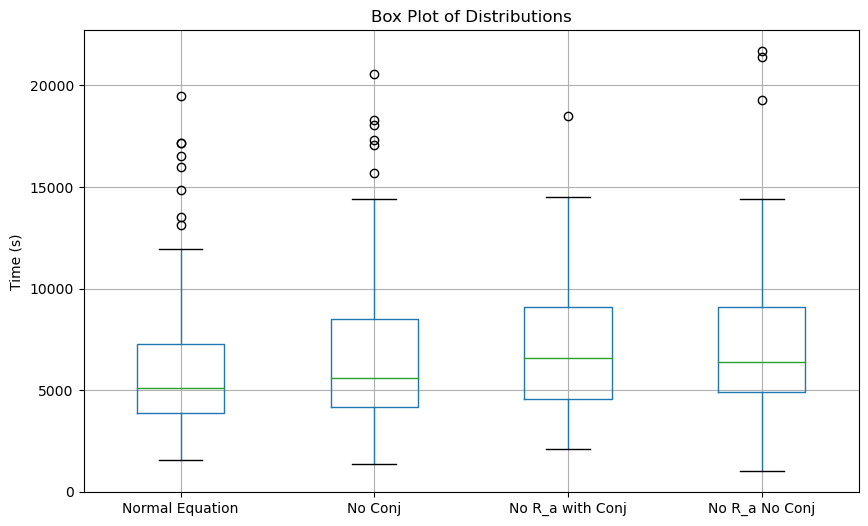

In [4]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Cleaning

In [5]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Equation'] = remove_outliers(df, 'Normal Equation')['Normal Equation']
df_cleaned['No Conj'] = remove_outliers(df, 'No Conj')['No Conj']
df_cleaned['No R_a with Conj'] = remove_outliers(df, 'No R_a with Conj')['No R_a with Conj']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']
df_cleaned.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,92.000000,94.000000,99.000000,97.000000
mean,5390.663043,6188.968085,6978.757576,6723.927835
std,2529.713293,3096.253263,2856.742979,2813.514003
min,1542.000000,1351.000000,2120.000000,1009.000000
25%,3418.000000,4031.750000,4567.000000,4870.000000
50%,5001.500000,5390.000000,6559.000000,6383.000000
75%,6807.500000,8003.500000,9070.000000,8160.000000
max,11935.000000,14386.000000,14518.000000,14410.000000


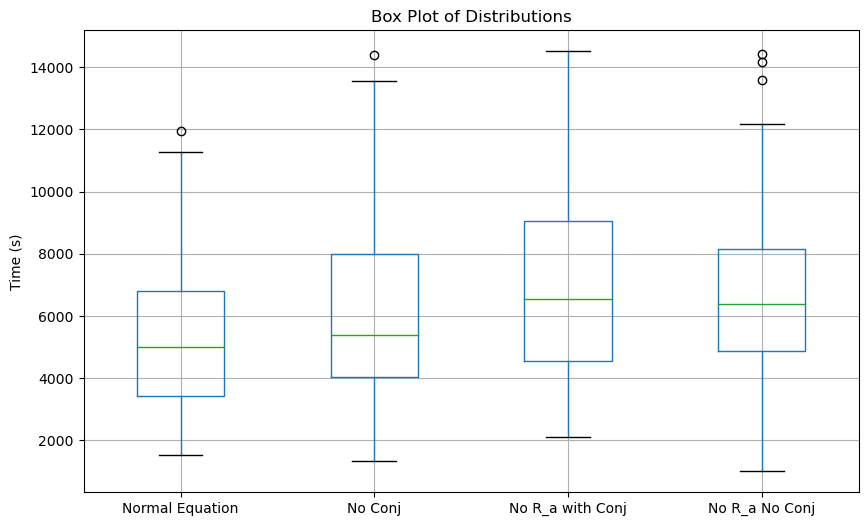

In [6]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Normalization and Histograms

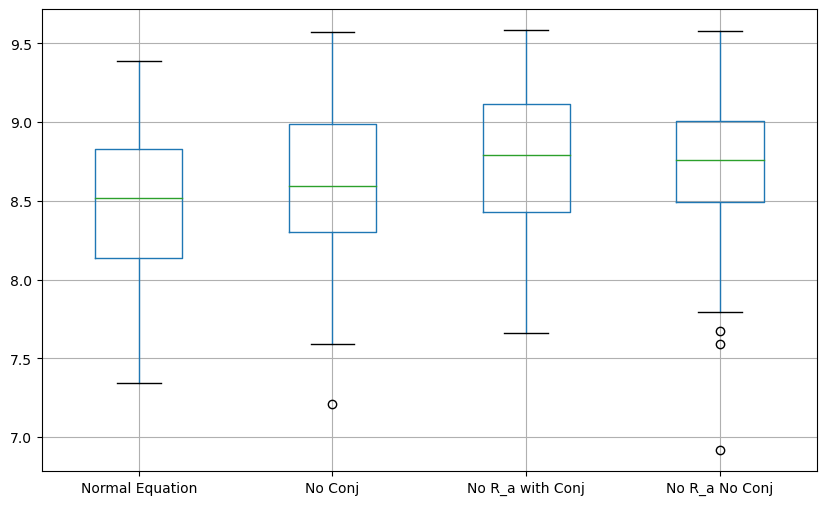

In [45]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Visualize the Data
plt.figure(figsize=(10, 6))
normalized_df_cleaned.boxplot()
plt.show()

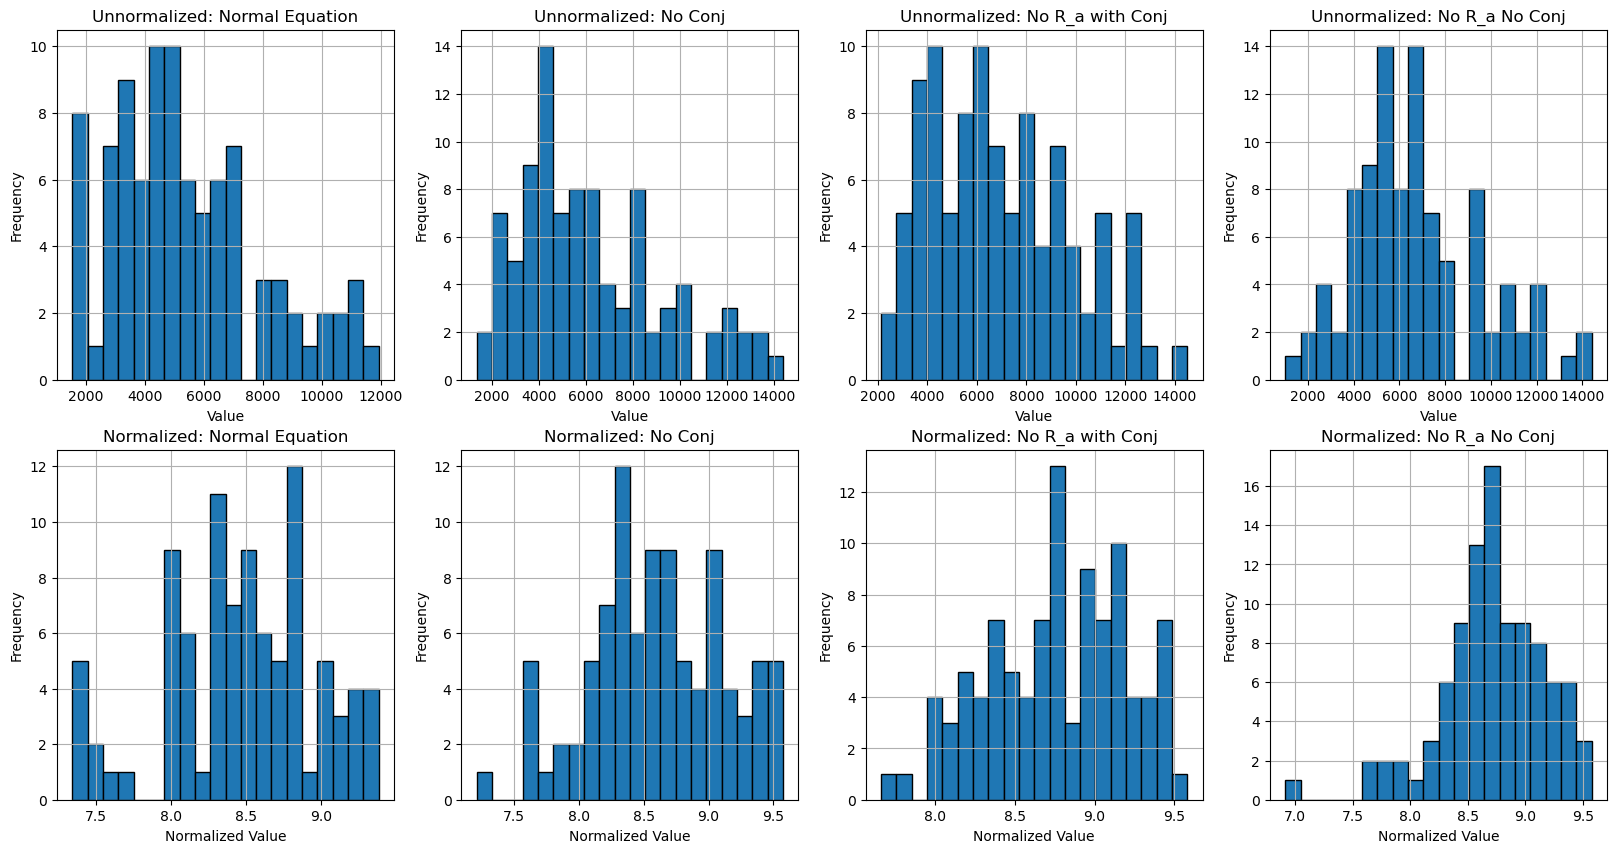

In [44]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=20, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=20, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

### Power Analysis

In [14]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Normal Equation'] = remove_outliers(df, 'Normal Equation')['Normal Equation']
df_cleaned['No Conj'] = remove_outliers(df, 'No Conj')['No Conj']
df_cleaned['No R_a with Conj'] = remove_outliers(df, 'No R_a with Conj')['No R_a with Conj']
df_cleaned['No R_a No Conj'] = remove_outliers(df, 'No R_a No Conj')['No R_a No Conj']
df_cleaned.describe()

,Normal Equation,No Conj,No R_a with Conj,No R_a No Conj
count,92.000000,94.000000,99.000000,97.000000
mean,5390.663043,6188.968085,6978.757576,6723.927835
std,2529.713293,3096.253263,2856.742979,2813.514003
min,1542.000000,1351.000000,2120.000000,1009.000000
25%,3418.000000,4031.750000,4567.000000,4870.000000
50%,5001.500000,5390.000000,6559.000000,6383.000000
75%,6807.500000,8003.500000,9070.000000,8160.000000
max,11935.000000,14386.000000,14518.000000,14410.000000


**Comparing Normal Equation data to others.**

Comparing the Normal Equation data, (unaltered model), with 'No R_a No Conj', (model where bacteria do not slow down in antibiotic, and have no conjugation).

In [7]:
# Calculate Skewness of a data set.
skew_normal = skew(df['Normal Equation'])
skew_no_ra_no_conj = skew(df['No R_a No Conj'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Normal Equation'], df['No R_a No Conj'].dropna())

skew_normal, skew_no_ra_no_conj, u_stat, p_value_u

(1.4239061887240152, 1.6678400777611189, 3938.0, 0.009495625258381641)

Skewness:
- Both distributions are positively skewed, as one can tell by their score.
- Normal Equation: 1.424
- No R_a No Conjugation: 1.668
- The smaller score for Normal Equation means the distribution is less skewed to the right, and more distributed around a lower time.

Median:
- Normal Equation: 5001.5
- No R_a No Conjugation: 6383.0

Mann-Whitney U Test:
- P-value: The p-value of 0.009 is less than the common significance level of 0.05.  We can conclude that the null hypothesis is rejected and there is significant differences between the two distributions.  
- Even given the small sample size there is significant difference after removing the outliers.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing in the 'Normal Equation' more likely to be lower as the median is lower than 'No R_a No Conj'.

In [9]:
# Calculate Skewness of a data set.
skew_normal = skew(df['Normal Equation'])
skew_no_ra_no_conj = skew(df['No R_a with Conj'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Normal Equation'], df['No R_a with Conj'].dropna())

skew_normal, skew_no_ra_no_conj, u_stat, p_value_u

(1.4239061887240152, 0.7834654749159082, 3882.0, 0.006323727546957127)

Skewness:
- Both distributions are positively skewed, as one can tell by their score.
- Normal Equation: 1.424
- No R_a with Conj: 0.783
- The smaller score for Normal Equation means the distribution is more skewed and has a longer right tail.

Median:
- Normal Equation: 5001.5
- No R_a with Conj: 6559.0

Mann-Whitney U Test:
- P-value: The p-value of 0.006 is less than the common significance level of 0.05.  We can conclude that the null hypothesis is rejected and there is significant differences between the two distributions.  
- Even given the small sample size there is significant difference after removing the outliers.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing in the 'Normal Equation' more likely to be lower as the median is lower than 'No R_a No Conj'.  While Normal Equation is more skewed, the distribution is more concentrated along a lower time than No R_a with Conj.

**Conclusion:**

    Even with the skew, the 75% percentile for the Normal Distribution is still lower than 'No R_a No Conj' and 'No R_a No Conj', (6807.5 vs 9070.0 and 8160.0).

    The median of the Normal Equation is lower than the other distributions.

    While the chemotaxis equation provides a negligible difference between distributions, if it is combined with R_a, it can help give the bacteria a significant advantage for fixing into a population.

**The Remaining Comparisons are not Statistically Significant**

In [13]:
# Normal Equation and No Conj are not statistically significant.
skew_normal = skew(df['Normal Equation'])
skew_no_conj = skew(df['No Conj'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Normal Equation'], df['No Conj'].dropna())

skew_normal, skew_no_conj, u_stat, p_value_u

(1.4239061887240152, 1.259974694380183, 4515.5, 0.23696428367165434)

In [12]:
# Mann-Whitney U Test for No Conj vs No R_a with Conj
u_stat_no_conj_no_ra_conj, p_value_no_conj_no_ra_conj = mannwhitneyu(df['No Conj'], df['No R_a with Conj'])
u_stat_no_conj_no_ra_conj, p_value_no_conj_no_ra_conj

(4406.5, 0.14735708931203692)

In [10]:
# Mann-Whitney U Test for No R_a with Conj vs No R_a No Conj
u_stat_no_ra_conj_no_ra_no_conj, p_value_no_ra_conj_no_ra_no_conj = mannwhitneyu(df['No R_a with Conj'], df['No R_a No Conj'])
u_stat_no_ra_conj_no_ra_no_conj, p_value_no_ra_conj_no_ra_no_conj

(5129.5, 0.7526118671123978)

In [11]:
# Mann-Whitney U Test for No Conj vs No R_a No Conj
u_stat_no_conj_no_ra_no_conj, p_value_no_conj_no_ra_no_conj = mannwhitneyu(df['No Conj'], df['No R_a No Conj'])
u_stat_no_conj_no_ra_no_conj, p_value_no_conj_no_ra_no_conj

(4445.0, 0.17546244064801408)

### Sample Sizes

In [35]:
# Calculate pooled standard deviation
n1 = df.shape[0]
n2 = df['No R_a No Conj'].dropna().shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_no_conj**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

In [36]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.NormalIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.11773745591169878, 1132.4194266886839)

In [13]:
# Calculate pooled standard deviation
n1 = n2 = df.shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_w_conjugation**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

Power Analysis Inputs:
- Effect size (Cohen's d): Use the effect size estimated from the pilot study.
- Significance level (α): Typically set at 0.05.
- Power (1 - β): Commonly set at 0.80 or 0.90.
- Two-tailed test: If you are interested in differences in both directions.